# Plotting Demo: `geodef.plot`

This notebook demonstrates every plot type in `geodef.plot`. Each cell is self-contained so you can evaluate the visual style and ease of use.

**Design principles:**
- Every function accepts `ax=None` (creates a figure) or an existing axes
- Every function returns the `ax` used, so you can keep customizing
- `**kwargs` pass through to the underlying matplotlib artist
- Never calls `plt.show()`

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import geodef
from geodef import Fault, GNSS, InSAR

## Setup: Create synthetic fault, data, and inversion result

We'll build a simple scenario: a dipping fault with prescribed slip, GNSS stations, and InSAR points. Then run an inversion to get a result we can plot.

In [19]:
# --- Fault ---
fault = Fault.planar(
    lat=0.0, lon=0.0, depth=5_000.0,
    strike=30.0, dip=50.0,
    length=40_000.0, width=25_000.0,
    n_length=5, n_width=4,
)
n = fault.n_patches
print(f"Fault: {fault}")

# --- Prescribed "true" slip (peaked in the center) ---
# IMPORTANT: Fault.planar orders patches as (down-dip outer, along-strike inner),
# i.e. shape (nW, nL) raveled in C order. Match that here.
rng = np.random.default_rng(42)
nL, nW = fault.grid_shape
jj, ii = np.meshgrid(np.arange(nW), np.arange(nL), indexing="ij")  # shape (nW, nL)
true_ss = 1.5 * np.exp(-0.5 * ((ii - nL/2)**2 + (jj - nW/2)**2) / 2.0).ravel()
true_ds = 2.0 * np.exp(-0.5 * ((ii - nL/2)**2 + (jj - nW/2)**2) / 1.5).ravel()
true_slip = np.concatenate([true_ss, true_ds])

# --- GNSS stations ---
gnss_lat = rng.uniform(-0.15, 0.15, 12)
gnss_lon = rng.uniform(-0.15, 0.15, 12)
ue, un, uz = fault.displacement(gnss_lat, gnss_lon, true_ss, true_ds)
sigma_val = 0.05
noise = rng.normal(0, sigma_val, (3, 12))
gnss = GNSS(
    gnss_lat, gnss_lon,
    ve=ue + noise[0], vn=un + noise[1], vu=uz + noise[2],
    se=np.full(12, sigma_val), sn=np.full(12, sigma_val),
    su=np.full(12, sigma_val * 2),
)

# --- InSAR points ---
insar_lat = rng.uniform(-0.15, 0.15, 80)
insar_lon = rng.uniform(-0.15, 0.15, 80)
ue_i, un_i, uz_i = fault.displacement(insar_lat, insar_lon, true_ss, true_ds)
look_e = np.full(80, -0.1)
look_n = np.full(80, 0.08)
look_u = np.full(80, 0.99)
los_true = look_e * ue_i + look_n * un_i + look_u * uz_i
insar = InSAR(
    insar_lat, insar_lon,
    los=los_true + rng.normal(0, 0.005, 80),
    sigma=np.full(80, 0.005),
    look_e=look_e, look_n=look_n, look_u=look_u,
)

# --- Inversion ---
result = geodef.invert(
    fault, [gnss, insar],
    smoothing="laplacian", smoothing_strength=1e3,
)
print(f"Inversion Mw={result.Mw:.2f}, chi2={result.reduced_chi2:.2f}")

Fault: Fault(n_patches=20, engine='okada', grid=(5, 4))
Inversion Mw=7.13, chi2=1469.35


---
## 1. `plot.slip` — Slip distribution on fault patches

The workhorse plot. Shows slip magnitude (or strike/dip component) as colored patches.

<Axes: xlabel='East (km)', ylabel='North (km)'>

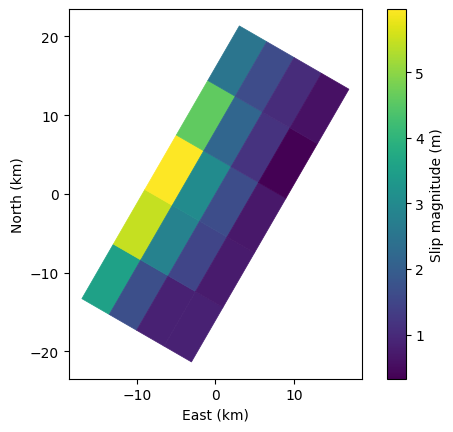

In [20]:
# Minimal: one line to get a nice plot
geodef.plot.slip(fault, result.slip_vector)

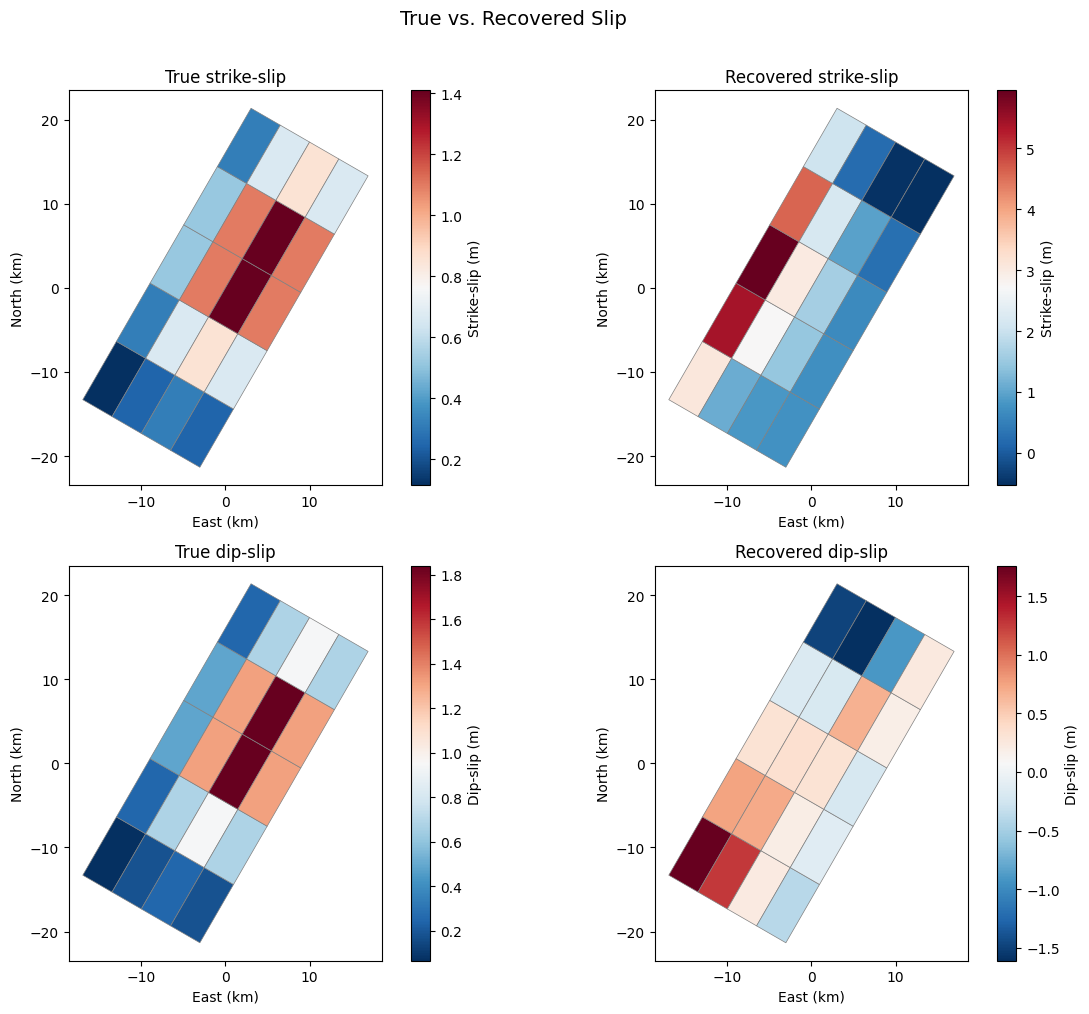

In [21]:
# Side-by-side: true vs recovered, strike and dip components
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

geodef.plot.slip(fault, true_slip, ax=axes[0, 0], components="strike",
                 cmap="RdBu_r", title="True strike-slip", edgecolor="gray")
geodef.plot.slip(fault, result.slip_vector, ax=axes[0, 1], components="strike",
                 cmap="RdBu_r", title="Recovered strike-slip", edgecolor="gray")
geodef.plot.slip(fault, true_slip, ax=axes[1, 0], components="dip",
                 cmap="RdBu_r", title="True dip-slip", edgecolor="gray")
geodef.plot.slip(fault, result.slip_vector, ax=axes[1, 1], components="dip",
                 cmap="RdBu_r", title="Recovered dip-slip", edgecolor="gray")
fig.suptitle("True vs. Recovered Slip", fontsize=14, y=1.01)
fig.tight_layout()

### `plot.patches` — Generic per-patch scalar

For any derived quantity (depth, area, coupling ratio, etc.) use `plot.patches` directly:

<Axes: title={'center': 'Patch center depth'}, xlabel='East (km)', ylabel='North (km)'>

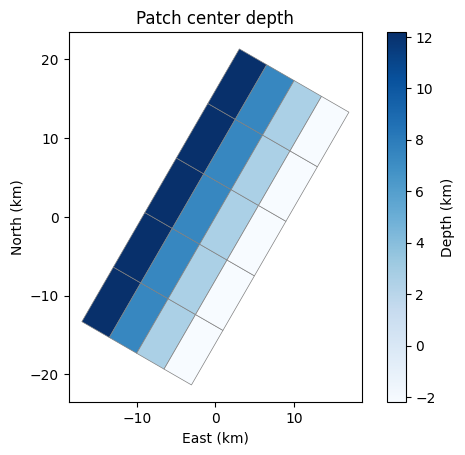

In [22]:
# Plot patch center depth (km)
geodef.plot.patches(fault, fault._depth * 1e-3,
                     cmap="Blues", edgecolor="gray",
                     colorbar_label="Depth (km)",
                     title="Patch center depth")

---
## 2. `plot.vectors` — GNSS displacement vectors

Quiver plot of observed (and optionally predicted) GNSS vectors with uncertainty ellipses.

<Axes: title={'center': 'GNSS: Observed vs. Predicted'}, xlabel='East (km)', ylabel='North (km)'>

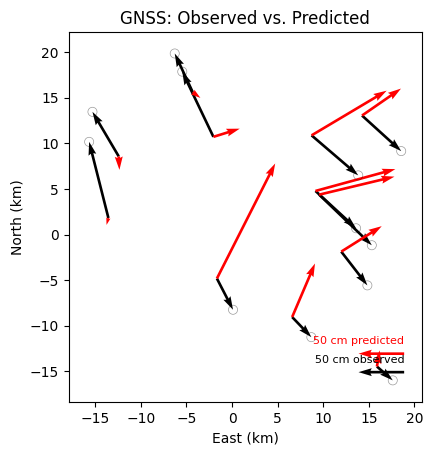

In [23]:
# Observed vs predicted GNSS vectors with scale arrow legend
# The 'scale' converts displacement (meters) to visible arrow length (km)
geodef.plot.vectors(gnss, fault, predicted=result.predicted[:gnss.n_obs],
                    scale=10, legend=True,
                    scale_arrow=0.5, scale_arrow_label="50 cm observed",
                    title="GNSS: Observed vs. Predicted")

<Axes: xlabel='East (km)', ylabel='North (km)'>

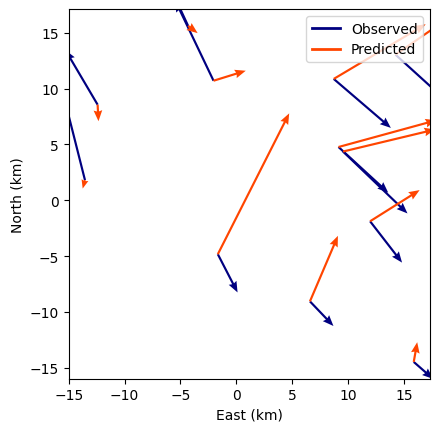

In [24]:
# Customized: no ellipses, different colors, thicker arrows
geodef.plot.vectors(gnss, fault,
                    predicted=result.predicted[:gnss.n_obs],
                    scale=10,
                    obs_color="navy", pred_color="orangered",
                    ellipses=False,
                    quiver_kwargs={"width": 0.006, "headwidth": 4},
                    legend=True)

<Axes: title={'center': 'GNSS Vertical Component'}, xlabel='East (km)', ylabel='North (km)'>

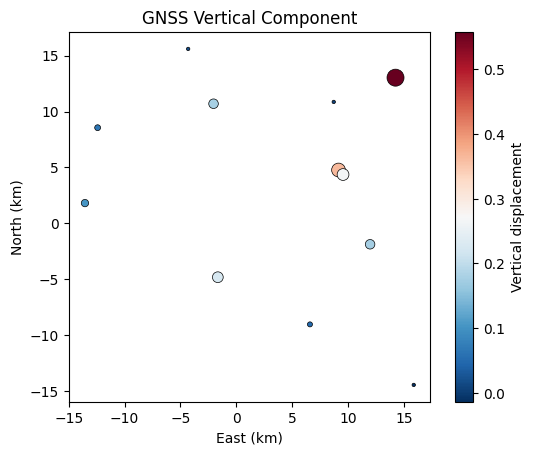

In [25]:
# Vertical component only (color-coded circles)
# 'scale' controls dot size (larger scale = bigger dots), color always shows raw values
geodef.plot.vectors(gnss, fault, scale=5, components="vertical",
                    title="GNSS Vertical Component")

---
## 3. `plot.insar` — InSAR LOS data

Scatter plot of LOS displacements. Supports single panels or side-by-side observed/predicted/residual.

<Axes: title={'center': 'InSAR LOS Observations'}, xlabel='East (km)', ylabel='North (km)'>

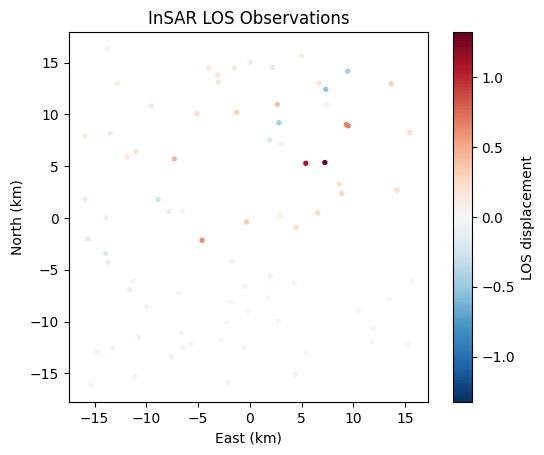

In [26]:
# Single panel: just the observations
geodef.plot.insar(insar, fault, title="InSAR LOS Observations")

array([<Axes: title={'center': 'Observed'}, xlabel='East (km)', ylabel='North (km)'>,
       <Axes: title={'center': 'Predicted'}, xlabel='East (km)'>,
       <Axes: title={'center': 'Residual'}, xlabel='East (km)'>],
      dtype=object)

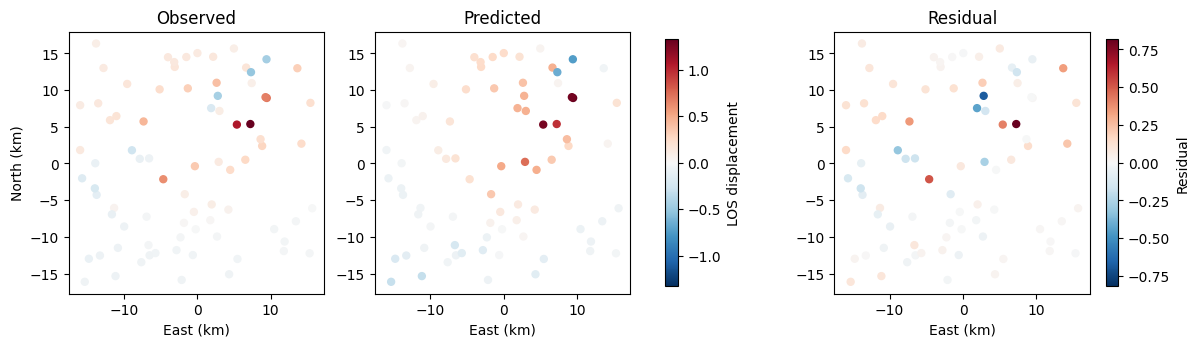

In [27]:
# Three-panel layout: observed, predicted, residual
pred_insar = result.predicted[gnss.n_obs:]  # InSAR portion of predicted vector
geodef.plot.insar(insar, fault, predicted=pred_insar, layout="obs_pred_res",
                  scatter_kwargs={"s": 25})

---
## 4. `plot.fit` — Observed vs. Predicted scatter

Quick diagnostic: does the model fit the data?

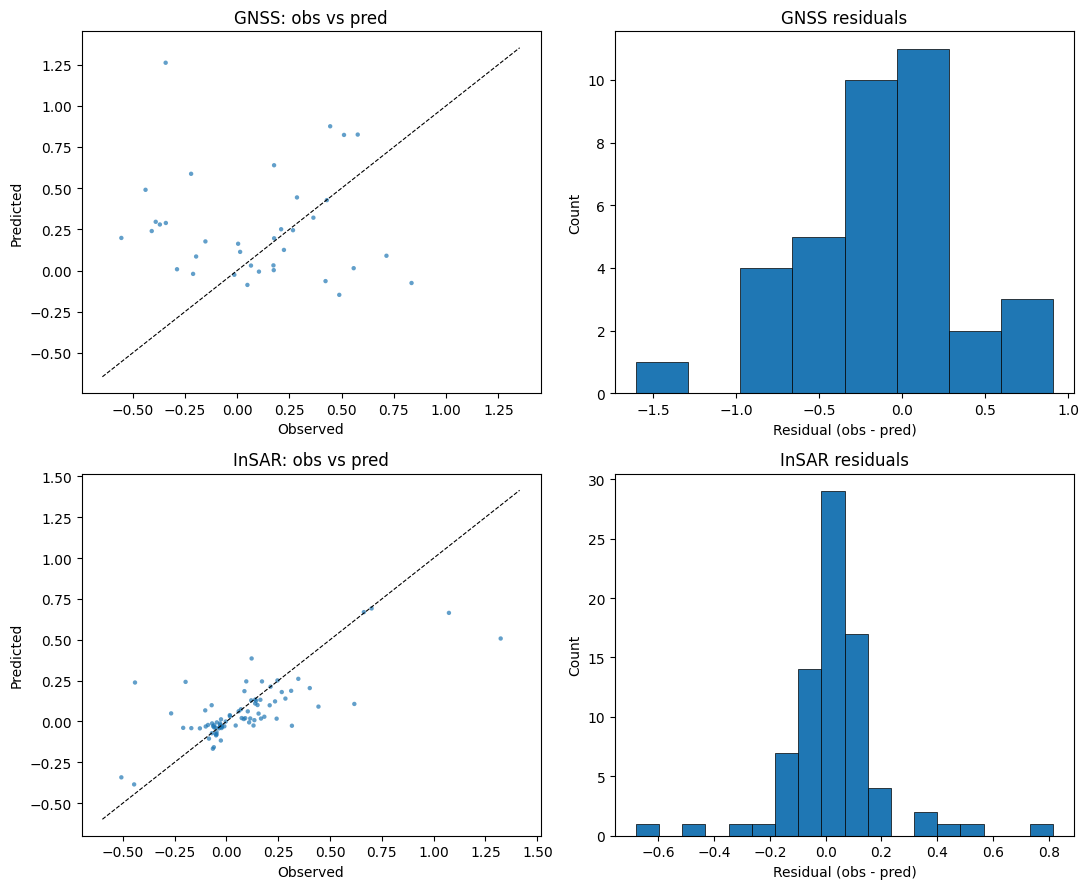

In [28]:
# Separate fit plots for each dataset
pred_gnss = result.predicted[:gnss.n_obs]
pred_insar = result.predicted[gnss.n_obs:]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# GNSS: obs vs pred + residual histogram
geodef.plot.fit(gnss.obs, pred_gnss, ax=axes[0, 0], title="GNSS: obs vs pred")
geodef.plot.fit(gnss.obs, pred_gnss, ax=axes[0, 1],
                style="residual_histogram", title="GNSS residuals")

# InSAR: obs vs pred + residual histogram
geodef.plot.fit(insar.obs, pred_insar, ax=axes[1, 0], title="InSAR: obs vs pred")
geodef.plot.fit(insar.obs, pred_insar, ax=axes[1, 1],
                style="residual_histogram", title="InSAR residuals")

fig.tight_layout()

---
## 5. `plot.resolution` and `plot.uncertainty` — Model diagnostics

Thin wrappers around the same patch-scalar plotting core, with appropriate default colormaps and labels.

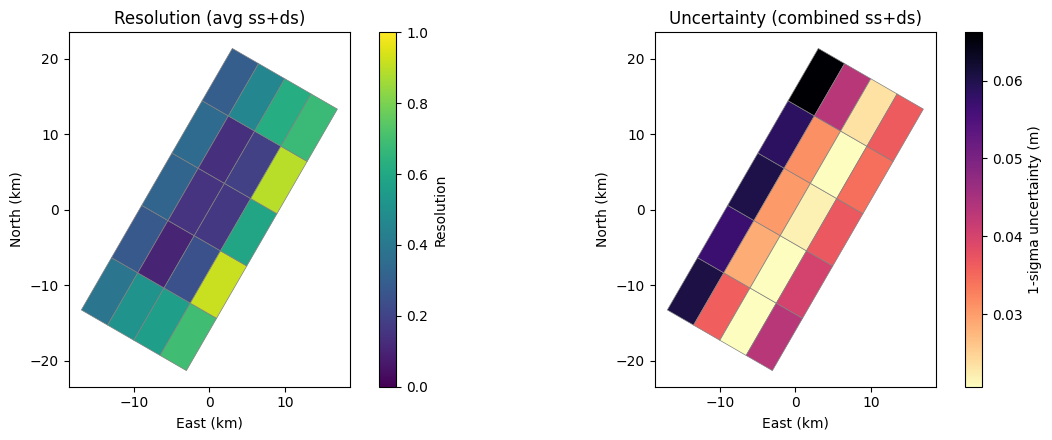

In [29]:
# Compute model resolution and uncertainty
R = geodef.model_resolution(result, fault, [gnss, insar])
R_diag = np.diag(R)
# Take the average of ss and ds resolution diagonals
R_avg = (R_diag[:n] + R_diag[n:]) / 2

sigma = geodef.model_uncertainty(result, fault, [gnss, insar])
# Average ss and ds uncertainty
sigma_avg = np.sqrt(sigma[:n]**2 + sigma[n:]**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
geodef.plot.resolution(fault, R_avg, ax=axes[0],
                        title="Resolution (avg ss+ds)", edgecolor="gray")
geodef.plot.uncertainty(fault, sigma_avg, ax=axes[1],
                         title="Uncertainty (combined ss+ds)", edgecolor="gray")
fig.tight_layout()

---
## 6. `plot.fault3d` — 3D fault geometry

Interactive 3D view of the fault mesh, colored by depth, area, or a custom array.

<Axes3D: title={'center': 'Fault geometry (depth)'}, xlabel='East (km)', ylabel='North (km)', zlabel='Depth (km)'>

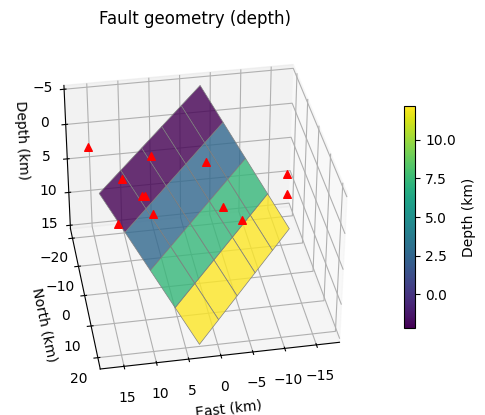

In [30]:
# 3D view colored by depth, with GNSS stations overlaid
# Use view=(elev, azim) to control the camera angle
geodef.plot.fault3d(fault, color_by="depth", cmap="viridis",
                    station_locations=gnss, view=(35, 80),
                    title="Fault geometry (depth)")

<Axes3D: title={'center': 'Fault 3D: slip magnitude'}, xlabel='East (km)', ylabel='North (km)', zlabel='Depth (km)'>

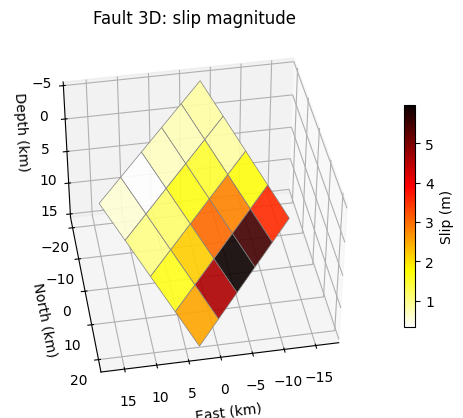

In [31]:
# Color by slip magnitude, different view angle
from geodef.plot import _get_slip_component
slip_mag = _get_slip_component(result.slip_vector, n, "magnitude")
geodef.plot.fault3d(fault, color_by=slip_mag, cmap="hot_r",
                    colorbar_label="Slip (m)", alpha=0.9,
                    view=(40, 80), title="Fault 3D: slip magnitude")

---
## 7. `plot.map` — 2D map view

Overview of fault geometry and data station locations in map view.

<Axes: title={'center': 'Map view: slip + data stations'}, xlabel='East (km)', ylabel='North (km)'>

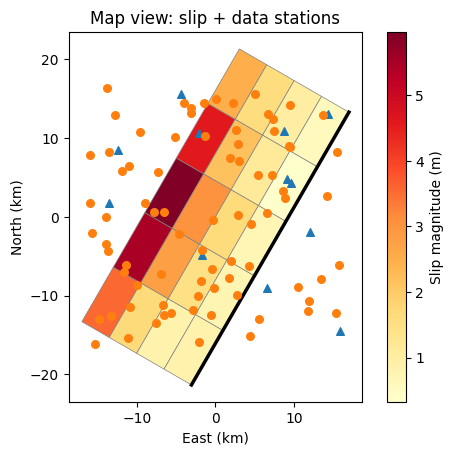

In [32]:
# Map with fault patches colored by slip magnitude, surface trace, and station locations
geodef.plot.map(fault,
                datasets=[gnss, insar],
                slip_vector=result.slip_vector,
                components="magnitude",
                cmap="YlOrRd",
                colorbar_label="Slip magnitude (m)",
                show_trace=True,
                patch_kwargs={"edgecolor": "gray"},
                trace_kwargs={"color": "black", "linewidth": 2.5},
                title="Map view: slip + data stations")

---
## 8. L-curve and ABIC plots (refactored)

These live on their result objects but now follow the same pattern: `ax=None`, `**kwargs`, return `ax`.

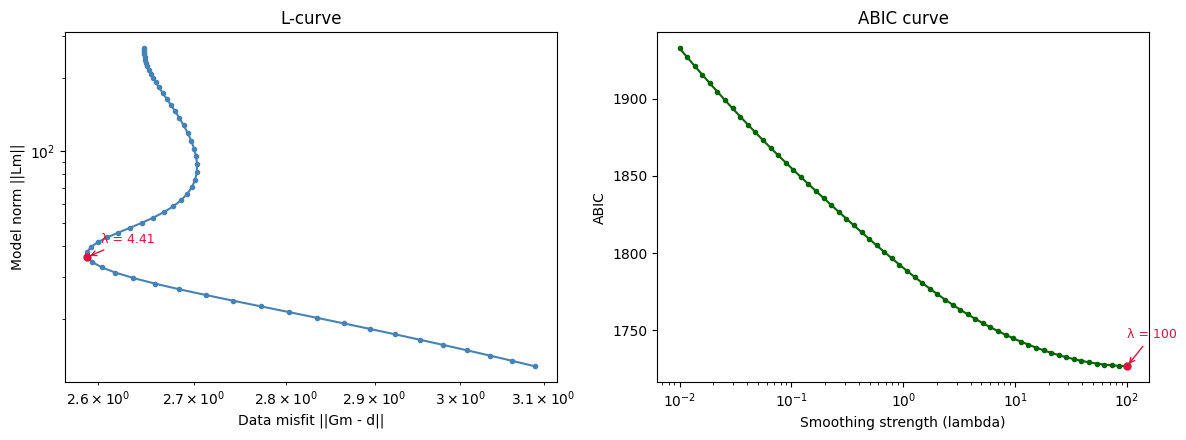

In [33]:
# Run L-curve and ABIC curve analyses
lc = geodef.lcurve(fault, [gnss, insar], smoothing="laplacian",
                   smoothing_range=(1e-2, 1e2), n=60)
ac = geodef.abic_curve(fault, [gnss, insar], smoothing="laplacian",
                       smoothing_range=(1e-2, 1e2), n=60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# L-curve with custom styling
lc.plot(ax=axes[0], line_kwargs={"color": "steelblue", "linewidth": 1.5},
        marker_kwargs={"color": "crimson", "markersize": 5})

# ABIC curve with custom styling
ac.plot(ax=axes[1], line_kwargs={"color": "darkgreen", "linewidth": 1.5},
        marker_kwargs={"color": "crimson", "markersize": 5})

fig.tight_layout()

---
## 9. Composing plots: slip + vectors on the same axes

Since every function accepts `ax`, you can layer plots freely.

Text(0.5, 1.0, 'Slip + GNSS vectors (composed)')

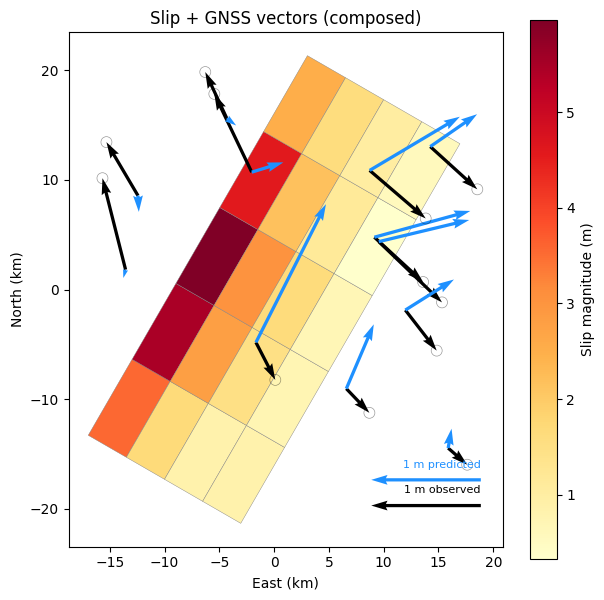

In [34]:
# Layer slip patches + GNSS vectors on a single axes
fig, ax = plt.subplots(figsize=(7, 7))

# First: slip patches as background
geodef.plot.slip(fault, result.slip_vector, ax=ax, coords="geographic",
                 edgecolor="gray", linewidth=0.3, cmap="YlOrRd",
                 colorbar_label="Slip magnitude (m)")

# Then: GNSS vectors on top with scale arrow legend
geodef.plot.vectors(gnss, fault, ax=ax,
                    predicted=result.predicted[:gnss.n_obs],
                    scale=10, legend=True,
                    scale_arrow=1, scale_arrow_label="1 m observed",
                    obs_color="black", pred_color="dodgerblue",
                    ellipses=True)

ax.set_title("Slip + GNSS vectors (composed)")